# Lab06: Non-linear optimization

## Libraries
We are using `optimize` , part of scipy

https://docs.scipy.org/doc/scipy/reference/optimize.html

In [1]:
# %matplotlib inline
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 2. One-dimensional problem

### Objective function, example:

$y =  x^4 - 10(x-1)^2 - 5x + 80$

We need to define objective function f1(x), and its derivative f1_p(x)


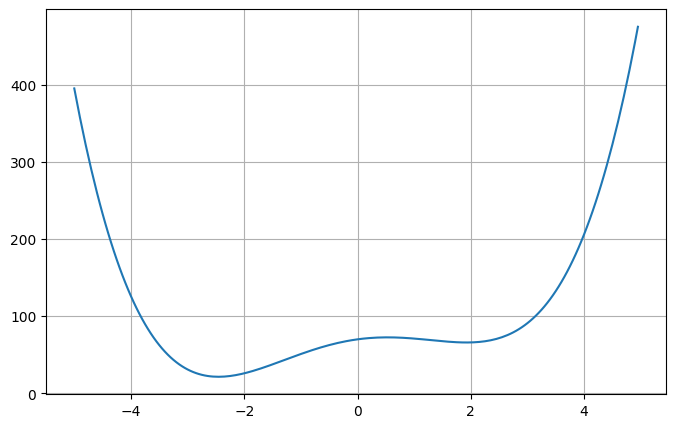

In [15]:
# 2.1 Define the function and its derivative

def f1(x):
    return x**4  -10*(x-1)**2 -10*x + 80

def f1_p(x):
    return 4*x**3 -20*(x-1) - 5
"""
Draw the function
"""
num_points = 200#how many points
start = -5 #starting point
end =  -start #end point
step = 2*abs(start)/num_points
point_x = []
data = []

for i in range(0,num_points):
    point_x.append(start+i*step)
    data.append(f1(start+i*step))
plt.plot(point_x, data)
plt.show()

In [4]:
# 2.2 Run the optimization

import scipy.optimize as spo
from scipy.optimize import OptimizeResult, minimize

# https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

#starting estimate
x_start = -5.0

opt_options = {'disp' : True}
tolerance = 1E-1
# Run minimize
res = minimize(f1, x_start, 
               method='BFGS', 
                   jac=f1_p, hess=None, hessp=None, bounds=None, constraints=(),
                   tol=tolerance, callback=None, options=opt_options)

print(res)


Optimization terminated successfully.
         Current function value: 9.006598
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 9.006597996983857
        x: [-2.545e+00]
      nit: 6
      jac: [-2.728e-02]
 hess_inv: [[ 1.651e-02]]
     nfev: 7
     njev: 7


In [5]:

# HELPER FUNCTION TO COLLECT RESULTS
# Perform minimization, store all iterations
def minimize_function_x (x0, function, opt_method = 'CG', opt_options = {'disp' : True}, opt_tol = None, jacobian = None):
    all_x_i = [x0]
    all_f_i = [function(x0)]

    def store(X):
        x = X
        all_x_i.append(x[0])
        fval = function(X)
        print('x: ', x[0], '  Function value:', fval[0])
        all_f_i.append(fval[0])

    # Call minimization algorithm
    opt_result = optimize.minimize(function, x0, method=opt_method, callback=store, tol = opt_tol, options=opt_options, jac = jacobian)
    return opt_result, all_x_i, all_f_i


x:  -8.99   Function value: 5658.83756401
x:  -6.560506921720785   Function value: 1393.6530976387414
x:  -5.178285337508688   Function value: 443.2041962370296
x:  -4.073199161365527   Function value: 118.25216712558449
x:  -3.3427138380352392   Function value: 32.974306194620134
x:  -2.8785322271411755   Function value: 12.619469423449885
x:  -2.6414773464370236   Function value: 9.287960734168536
x:  -2.559019741184071   Function value: 9.012810203747833
x:  -2.5450947191559155   Function value: 9.006606530311686
x:  -2.5443797066767786   Function value: 9.006591551723005
x:  -2.544374157178177   Function value: 9.006591550834045
         Current function value: 9.006592
         Iterations: 11
         Function evaluations: 60
         Gradient evaluations: 48

 Miminization returned: 
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 9.006591550834045
        x: [-2.544e+00]
      nit: 11
      jac: [-1.221e-07]
 hess

c:\Python312\Lib\site-packages\scipy\optimize\_minimize.py:726: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\janezzaletelj\AppData\Local\Temp\ipykernel_22452\3883708874.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0,200])


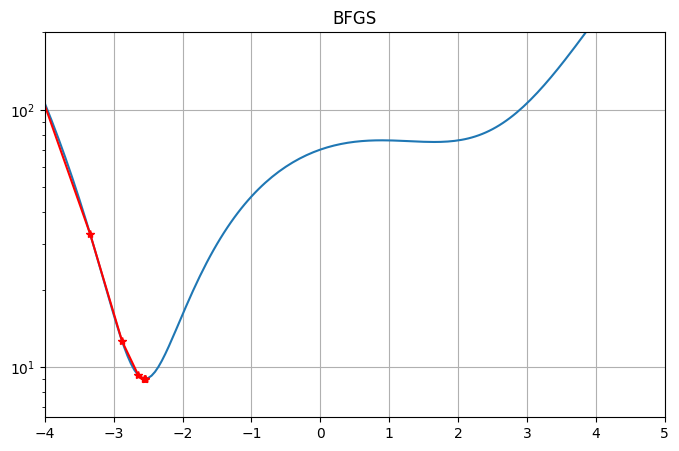

In [14]:
# 2.3 Primerjava metod

# Set optimization parameters:
xstart = -10
opt_method = 'BFGS'   #'Nelder-Mead' #'CG''BFGS' 'Newton-CG'
#opt_method = 'Newton-CG'   #'Nelder-Mead' #'CG''BFGS' 'Newton-CG'
opt_options = {'disp' : True}
opt_tol = 1E-7

# Run minimization
opt_res = minimize_function_x(xstart, f1, opt_method = opt_method, opt_tol=opt_tol, 
                              jacobian = f1_p)

print('\n Miminization returned: ')
print( opt_res[0] )

# 2.2 Vizualizacija
plt.plot(point_x,  data)
plt.plot(opt_res[1], opt_res[2], 'r*-')

plt.yscale('log')
plt.title(opt_method)
plt.xlim([-4,5])
plt.ylim([0,200])
plt.show()


### Metoda konjugiranega gradienta / Conjugate gradient descent
Metoda je gradientna metoda podobno kot Newtonova, vendar bolj natančno izračuna smer z ortogonalizacijo gradientnega vektorja, kar pomeni hitrejši spust in manj iteracij (hitrejšo konvergenco) za doseganje minimuma. 

> Conjugate gradient descent (CG) works in a similar fashion as Netwton's method, but tries to accelerate the convergence speed(i.e. how fast we find the solution). It achieves this by orthogonalizing the gradient vector - making it's descend steeper and thus faster. The orthogonalizing is based on the Grahm-Schmidt procedure. The function can work without the gradient (f_p) but will resort to a numerical estimate in such a case.

### Simpleksna metoda / Downhill simplex method

Metoda direktnega iskanja, ki ne potrebuje odvoda, saj primerja funkcijske vrednosti na robovih simpleksa in napreduje v smeri manjših vrednosti.  

> In the most simplified version - simplex algorithm works by trailing along the edges of feasible space (defined as a polytope) in the assumption that one of the vertices contains the desired extreme point (= lowest value). In a way it is similar to the graphical solution of the LP problem except that it works in a much more complex space. Another advantage is that it does not require the gradient function.

https://en.wikipedia.org/wiki/Nelder%E2%80%93Mead_method

### 2.4: Transmitter characteristic / Oddajniki maksimalna moč


> We have a system of four transmitters, with 10m between each. The transmitter characteristic (of each piece) on the x-axis is:

$amp*\frac{r^2}{(r^2+x^2)^{3/2}}$

> Assuming $amp=-1$ and $r=3$ for all four transmitters, we write down the transmission power along the x-axis. 
Our goal is to determine the point with the maximum transmitted power in the range between -10 and 50 meters.
To do this we first define the transmission functions and their gradients.



In [16]:
#single antenna
r = 7
def odd(x):
    return r**2*(x**2+r**2)**(-3/2)
#all four antennas
def f2(x):
    return -odd(x)-odd(x-10)-odd(x-20)-odd(x-40)

#gradient
def odd_p(x):
    return -3*r**2*x*(x**2+r**2)**(-5/2)
# gradient of the whole configuration
def f2_p(x):
    return -odd_p(x)-odd_p(x-10)-odd_p(x-20)-odd_p(x-40)

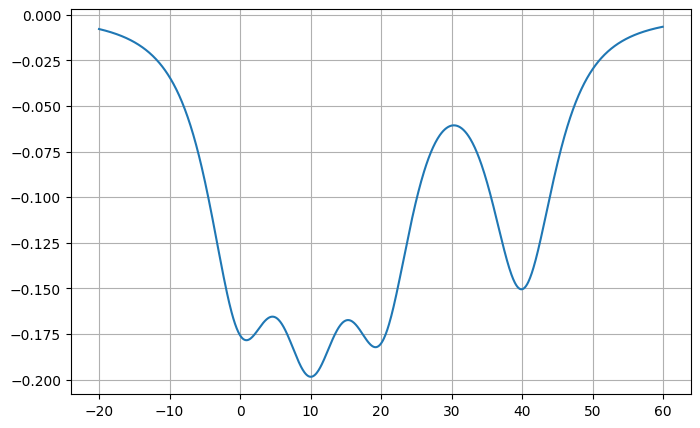

In [22]:
"""
Plot the power
"""
st_tock = 1000
zacetek = -20.0
konec =  60
step = (konec-zacetek)/st_tock
point_x = []
data = []

for i in range(0,st_tock):
    point_x.append(zacetek+i*step)
    data.append(f2(zacetek+i*step))
    
plt.figure()
plt.plot(point_x, data)
plt.show()

x:  5.774712061610284   Function value: -0.16866019959690526
x:  9.604702220451948   Function value: -0.1978734338450866
x:  10.036202762907784   Function value: -0.19841730949285546
x:  10.025752156306577   Function value: -0.19841764587354727
x:  10.025752156306577   Function value: -0.19841764587354727
Optimization terminated successfully.
         Current function value: -0.198418
         Iterations: 5
         Function evaluations: 9
         Gradient evaluations: 13
         Hessian evaluations: 0

 Miminization returned: 
 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -0.19841764587354727
       x: [ 1.003e+01]
     nit: 5
     jac: [-5.026e-08]
    nfev: 9
    njev: 13
    nhev: 0


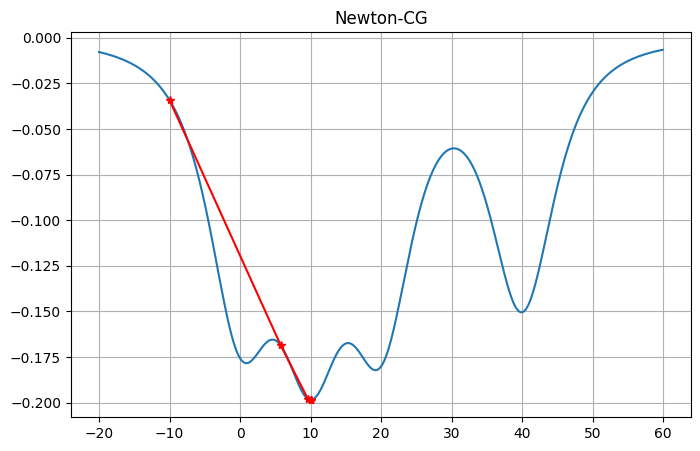

In [25]:
# Optimizacija: 
xstart = -10
opt_method = 'Newton-CG' #'CG'
opt_options = {'disp' : True}
opt_tol = 1E-10



# Run minimization
opt_res = minimize_function_x(xstart, f2, opt_method = opt_method, opt_tol=opt_tol, 
                              jacobian = f2_p)

print('\n Miminization returned: ')
print( opt_res[0] )

# 2.2 Vizualizacija
plt.figure()
plt.plot(point_x,  data)
plt.plot(opt_res[1], opt_res[2], 'r*-')
#plt.yscale('log')
plt.title(opt_method)

plt.show()

## 3. Two dimensional problems


> All of the presented methods also work in multiple dimensions. Unfortunatelly they also require some additional computation since the gradient function now becomes composed of partial gradients. We will demonstrate this on the Rosenbock function which is given as:  

$0.5(1-x)^2+(y-x^2)^2$

In [26]:
# ROSENBROCK FUNKCIJA
def fR(x): #Rosenbrock
    return .5* (1-x[0])**2+ (x[1] - x[0]**2)**2
    
def fR_p(x):  #Rosenbrock partial gradients (d/dx, d/dy)
    return np.array((-2*.5*(1-x[0]) - 4*x[0]*(x[1] - x[0]**2), 2*(x[1] - x[0]**2)))



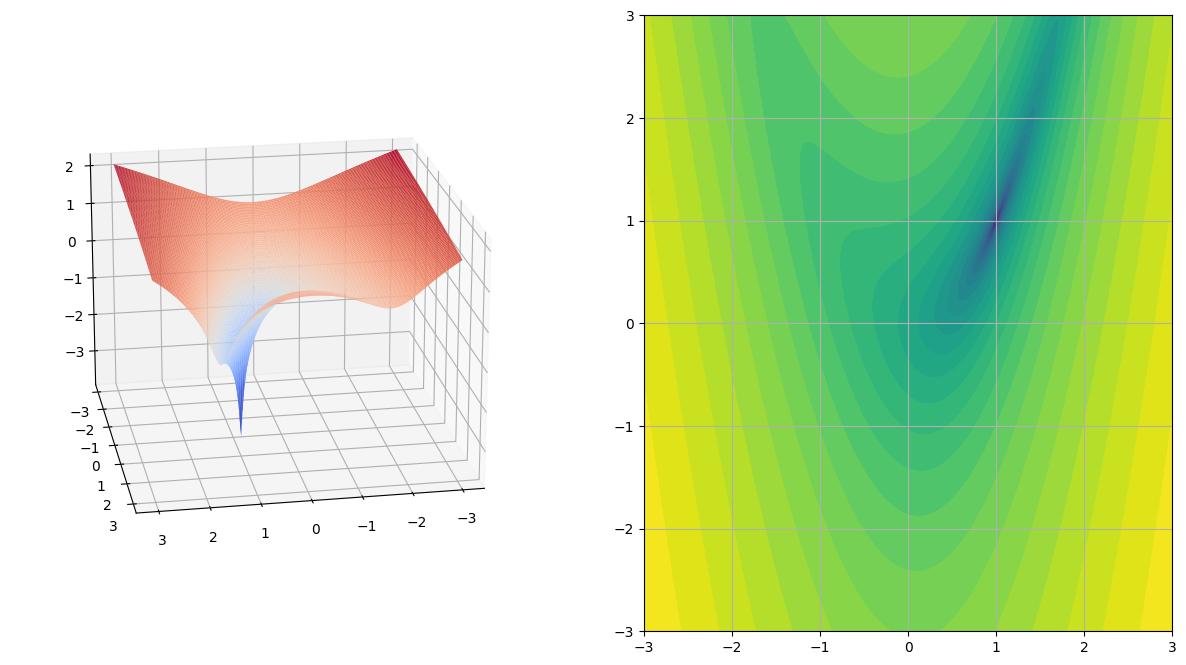

In [27]:
import numpy as np
from matplotlib import cm

# 3D visualisation
N = 200
min = -3
max =  3
tocke = np.linspace(min,max,N).tolist();

axis1 = []
axis2 = []
data = []
tmp1 = []
tmp2 = []
tmp3 = []
for i in range(0,N):
    for j in range(0,N):
        tmp1.append(tocke[i])
        tmp2.append(tocke[j])
        tmp3.append(fR([tocke[i],tocke[j]]))

    axis1.append(tmp1)
    axis2.append(tmp2)
    data.append(tmp3)
    tmp1 = []
    tmp2 = []
    tmp3 = []

fig = plt.figure(figsize=[15,8])
ax = fig.add_subplot(1,2,1, projection='3d')
#ax.plot_surface(axis1, axis2, np.log10(data), rstride=2, cstride=2, cmap=cm.coolwarm, antialiased=True)
ax.plot_surface(axis1, axis2, np.log10(data), rstride=2, cstride=2, cmap=cm.coolwarm, antialiased=True)

ax2 = fig.add_subplot(1,2,2)
ax2.contourf(axis1, axis2, np.log10(data), levels = 30)

ax.view_init(20, 80)
plt.show()

In [28]:
# Perform minimization, store all iterations
def minimize_function_xy (x0, function, opt_method = 'CG', opt_options = {'disp' : True}, jacobian = None):
    all_x_i = [x0[0]]
    all_y_i = [x0[1]]
    all_f_i = [function(x0)]

    def store(X):
        x, y = X
        all_x_i.append(x)
        all_y_i.append(y)
        all_f_i.append(function(X))
    
    # Call minimization algorithm
    opt_result = optimize.minimize(function, x0, method=opt_method, callback=store, options=opt_options, jac=jacobian)

    return opt_result, all_x_i, all_y_i, all_f_i



In [37]:
# 3.2 Compare methods

point0 = [-3,3]
opt_method = 'Nelder-Mead'

opt_res = minimize_function_xy(point0, fR, opt_method = opt_method, jacobian=fR_p)

print(opt_res[0])

def calc_error(point, true_point):
        error = np.sqrt( (point[0]-true_point[0])**2 + 
                        (point[1]-true_point[1])**2)
        return error

print('Optimization result: ', opt_res[0].x)
print('Error: ', calc_error(opt_res[0].x, [1.0, 1.0]))

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 67
         Function evaluations: 123
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.772665603268195e-10
             x: [ 1.000e+00  1.000e+00]
           nit: 67
          nfev: 123
 final_simplex: (array([[ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00],
                       [ 1.000e+00,  1.000e+00]]), array([ 1.773e-10,  1.795e-10,  7.979e-10]))
Optimization result:  [1.00001682 1.00003963]
Error:  4.304912767360384e-05


C:\Users\janezzaletelj\AppData\Local\Temp\ipykernel_22452\2410887187.py:14: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  opt_result = optimize.minimize(function, x0, method=opt_method, callback=store, options=opt_options, jac=jacobian)


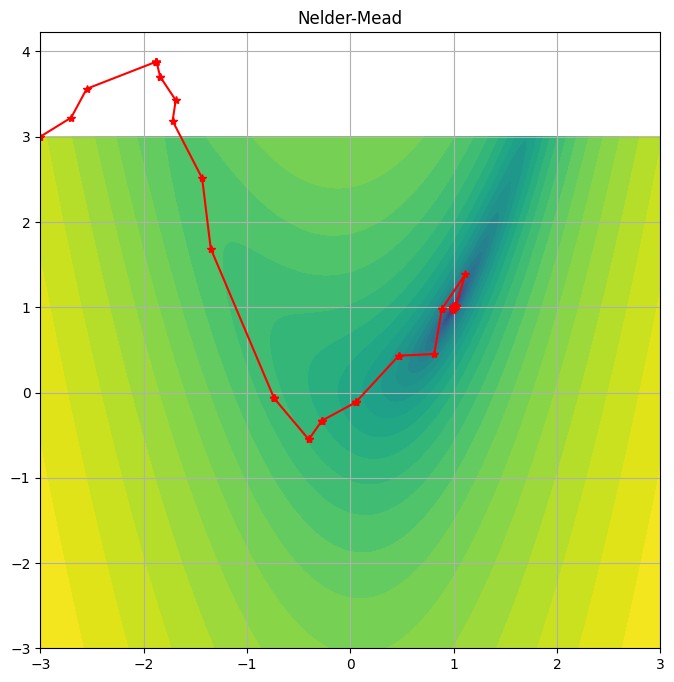

In [38]:
# Visualization 
fig = plt.figure(figsize=[8,8])
ax2 = fig.gca()
ax2.contourf(axis1, axis2, np.asarray(np.log10(data)), levels = 30)

# plot optimiz result
ax2.plot(opt_res[1],opt_res[2], 'r*-')

plt.title(opt_method)

#plt.xlim([-1,1.1])
#plt.ylim([-0.5,1.5])
plt.show()

## 4. Curve fitting problem



In [40]:
def linear2(x, a, b):
    return a * x + b 

def exp3(x, a, b, c):
    return a * np.exp(b * x) + c

def logistic4(x, L, k, x0, c):
    return L / (1 + np.exp(-k * (x - x0))) + c

def gaussian4(x, A, mu, sigma, c):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + c

def double_exp5(x, a1, b1, a2, b2, c):
    return a1 * np.exp(b1 * x) + a2 * np.exp(b2 * x) + c

def damped_sine5(x, A, gamma, omega, phi, c):
    return A * np.exp(-gamma * x) * np.sin(omega * x + phi) + c

def rational5(x, a, b, c, d, e):
    return (a * x + b) / (c * x + d) + e

MODEL_SPECS = {
    "linear2": {
        "func": linear2,
        "param_names": ["a", "b"],
        "default_init": [1.0, 0.0],
        "description": "2-parameter linear"
    },
    
    "exp3": {
        "func": exp3,
        "param_names": ["a", "b", "c"],
        "default_init": [1.0, -0.2, 0.0],
        "description": "3-parameter exponential"
    },
    "logistic4": {
        "func": logistic4,
        "param_names": ["L", "k", "x0", "c"],
        "default_init": [1.0, 1.0, 0.0, 0.0],
        "description": "4-parameter logistic / sigmoid"
    },
    "gaussian4": {
        "func": gaussian4,
        "param_names": ["A", "mu", "sigma", "c"],
        "default_init": [1.0, 0.0, 1.0, 0.0],
        "description": "4-parameter Gaussian peak"
    },
    "double_exp5": {
        "func": double_exp5,
        "param_names": ["a1", "b1", "a2", "b2", "c"],
        "default_init": [1.0, -0.2, 0.5, -1.0, 0.0],
        "description": "5-parameter double exponential"
    },
    "damped_sine5": {
        "func": damped_sine5,
        "param_names": ["A", "gamma", "omega", "phi", "c"],
        "default_init": [1.0, 0.2, 4.0, 0.0, 0.0],
        "description": "5-parameter damped sine"
    },
    "rational5": {
        "func": rational5,
        "param_names": ["a", "b", "c", "d", "e"],
        "default_init": [1.0, 0.0, 0.1, 1.0, 0.0],
        "description": "5-parameter rational function"
    },
}

### 4.1 Using curve_fit()

Estimated parameters: [ 1.44698886 -0.97310345 -0.07180459]
True parameters     : (2, -2, 0)
Parameter errors   : [0.19918029 0.34882464 0.13127099]


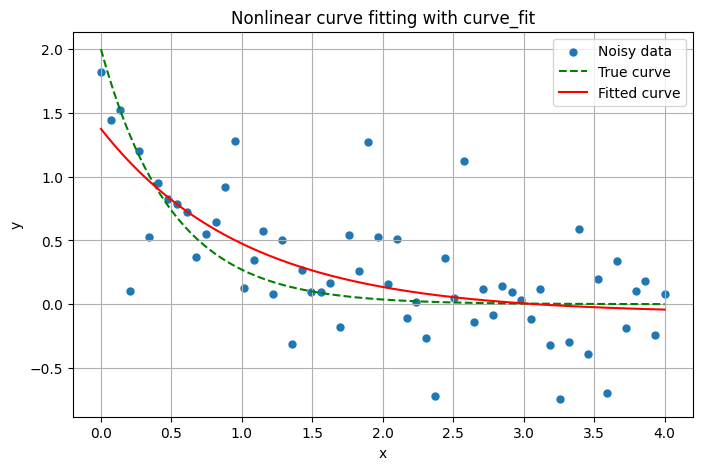

In [49]:
# 4.1 Example : Using curve_fit to fit an exponential model to synthetic data

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Select model
model = exp3

# Synthetic data
x = np.linspace(0, 4, 60)
true_params = (2, -2, 0)
y_true = model(x, *true_params)
y_noisy = y_true + 0.4 * np.random.normal(size=x.size)

# Initial guess
p0 = [0.0, -0.5, 3]

# Fit
popt, pcov = curve_fit(model, x, y_noisy, p0=p0)

print("Estimated parameters:", popt)
print("True parameters     :", true_params)
print("Parameter errors   :", np.sqrt(np.diag(pcov)))

# Plot
x_fine = np.linspace(x.min(), x.max(), 400)

plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, s=25, label="Noisy data")
plt.plot(x_fine, model(x_fine, *true_params), label="True curve", color="green", linestyle="--")
plt.plot(x_fine, model(x_fine, *popt), label="Fitted curve", color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear curve fitting with curve_fit")
plt.legend()
plt.grid(True)
plt.show()

### 4.2 Using Minimize() for curve fitting / za prileganje krivulje

Optimization terminated successfully.
         Current function value: 7.149407
         Iterations: 27
         Function evaluations: 51
Estimated parameters: [ 2.61629478 -0.6911261  -0.0076988 ]
Final SSE: 7.1494071821329594
Optimization path (parameters at each accepted step):
[[ 1.00000000e+00 -2.00000000e-01  0.00000000e+00]
 [ 1.05000000e+00 -2.00000000e-01  0.00000000e+00]
 [ 1.08333333e+00 -1.90000000e-01  4.16666667e-04]
 [ 1.16666667e+00 -1.80000000e-01  8.33333333e-05]
 [ 1.23333333e+00 -1.90000000e-01  1.66666667e-04]
 [ 1.23333333e+00 -1.90000000e-01  1.66666667e-04]
 [ 1.36481481e+00 -1.72222222e-01  4.62962963e-05]
 [ 1.41358025e+00 -1.77037037e-01  3.54938272e-04]
 [ 1.46728395e+00 -1.92592593e-01 -3.20987654e-04]
 [ 1.46728395e+00 -1.92592593e-01 -3.20987654e-04]
 [ 1.47551440e+00 -2.10493827e-01  3.80658436e-05]
 [ 1.43991770e+00 -2.34320988e-01 -8.96090535e-04]
 [ 1.73415638e+00 -2.66790123e-01 -1.37242798e-03]
 [ 1.71502058e+00 -3.26419753e-01 -1.58847737e-03]
 [ 1

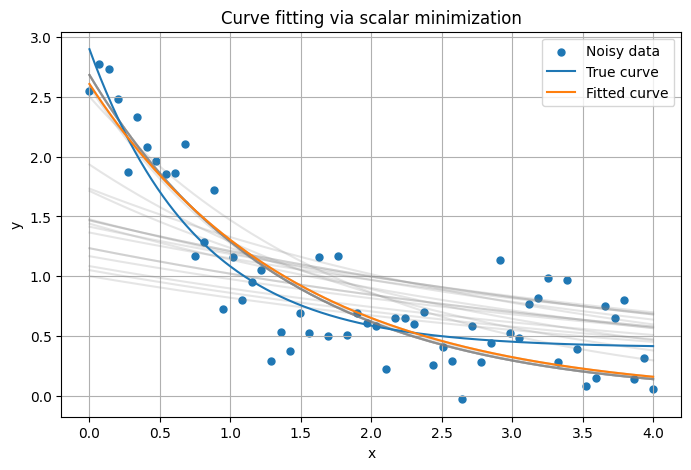

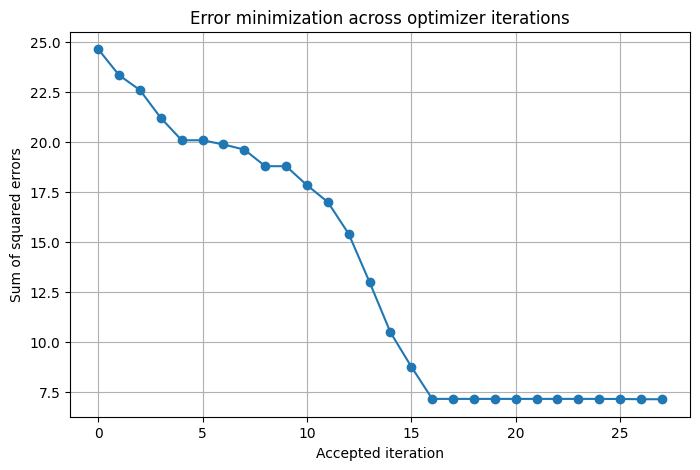

In [63]:
# 4.2 Example: Using minimize to fit an exponential model to synthetic data

# Random generator
rng = np.random.default_rng(100)

# Define model
model = exp3

# Data
x = np.linspace(0, 4, 60)
true_params = np.array([2.5, -1.3, 0.4])
y_true = model(x, *true_params)
y_noisy = y_true + 0.3 * rng.normal(size=x.size)

# Objective: sum of squared errors
def sse(params):
    y_pred = model(x, *params)
    return np.sum((y_pred - y_noisy)**2)

# Track accepted optimizer steps
history = []

def callback(params):
    history.append((params.copy(), sse(params)))

x0 = np.array([1.0, -0.2, 0.0])

result = minimize(
    sse,
    x0,
    method="Nelder-Mead",   #"BFGS",
    callback=callback,
    options={"disp": True},
    tol=1e-1
)



print("Estimated parameters:", result.x)
print("Final SSE:", result.fun)

# Include initial point in plots
full_params = [x0] + [h[0] for h in history]
full_sse = [sse(x0)] + [h[1] for h in history]

hist_params = np.array(full_params)
print("Optimization path (parameters at each accepted step):"   )
print(hist_params)

# Plot fit
x_fine = np.linspace(x.min(), x.max(), 400)
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, s=25, label="Noisy data")
for params in full_params:
    plt.plot(x_fine, model(x_fine, *params), color="gray", alpha=0.2)

plt.plot(x_fine, model(x_fine, *true_params), label="True curve")
plt.plot(x_fine, model(x_fine, *result.x), label="Fitted curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve fitting via scalar minimization")
plt.legend()
plt.show()

# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(full_sse, marker="o")
plt.xlabel("Accepted iteration")
plt.ylabel("Sum of squared errors")
plt.title("Error minimization across optimizer iterations")
#plt.yscale("log")
plt.show()

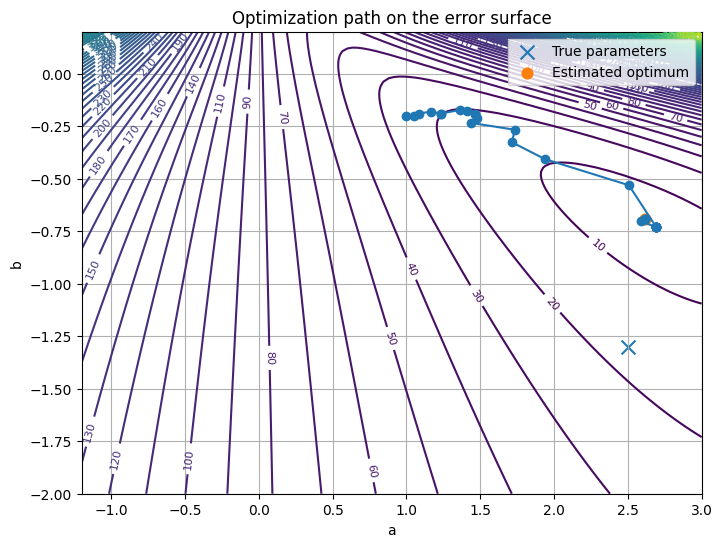

In [64]:
# Visualize optimization path on contour plot of error surface (only a and b dimensions)

hist_params = np.array(full_params)

# Build contour grid
a_vals = np.linspace(-1.2, 3, 120)
b_vals = np.linspace(-2.0, 0.2, 120)
A, B = np.meshgrid(a_vals, b_vals)
Z = np.zeros_like(A)

opt_parameters = result.x  # Only a and b for contour plot

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        params = opt_parameters.copy()
        # Fix c at optimized value
        params[0] = A[i, j]
        params[1] = B[i, j]
        Z[i, j] = sse(params)

plt.figure(figsize=(8, 6))
cs = plt.contour(A, B, Z, levels=100, cmap="viridis")
plt.clabel(cs, inline=True, fontsize=8)

plt.plot( hist_params[:,0], hist_params[:,1], marker="o")
plt.scatter(*true_params[:2], marker="x", s=100, label="True parameters")
plt.scatter(*result.x[:2], s=60, label="Estimated optimum")

plt.xlabel("a")
plt.ylabel("b")
plt.title("Optimization path on the error surface")
plt.legend()
plt.grid(True)
plt.show()

### 4.3 Starting estimate

Optimization terminated successfully.
         Current function value: 9.409377
         Iterations: 39
         Function evaluations: 486
         Gradient evaluations: 81
Estimated parameters: [-2.18646431  0.40058305 -5.98879054 -0.50778694  0.11263204]
Final SSE: 9.409376502023225
Optimization path (parameters at each accepted step):
[[-3.00000000e+00  5.00000000e-01  5.00000000e-01 -4.00000000e+00
   0.00000000e+00]
 [-2.76026176e+00  7.48467431e-01  7.46910849e-01 -3.17521094e+00
   3.99559185e-01]
 [-2.39686325e+00  1.51707412e+00  7.08493664e-01 -2.60481858e+00
   2.37310396e-01]
 [-2.32345088e+00  1.66334291e+00  6.45593022e-01 -2.68575400e+00
  -1.34143024e-01]
 [-2.26588118e+00  2.33189517e+00  2.93316445e-02 -1.70986172e+00
  -2.01065145e-01]
 [-2.23895580e+00  2.41006475e+00 -1.43040957e-02 -1.65462891e+00
  -9.58148410e-02]
 [-1.87220284e+00  3.05192039e+00 -2.16839524e-01 -1.49059537e+00
   3.05783082e-02]
 [-1.86174669e+00  3.09067346e+00 -2.26660643e-01 -1.48725088e+00

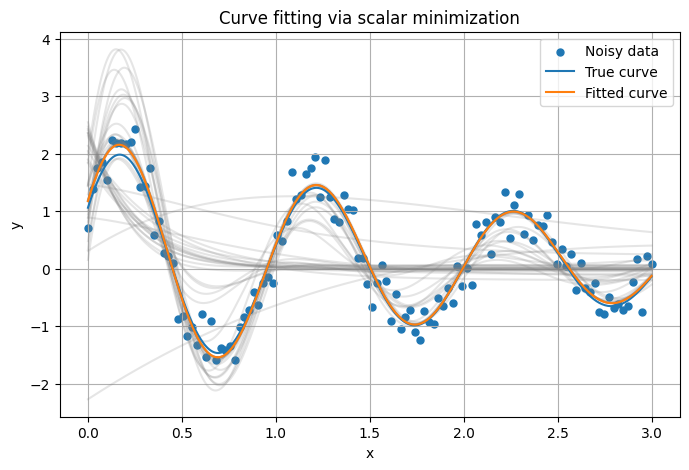

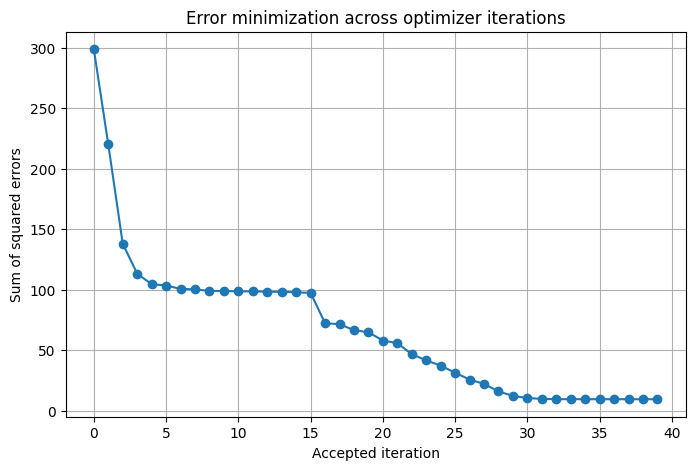

In [66]:
# Random generator
rng = np.random.default_rng(100)

# Define model
model = damped_sine5

# Data
x = np.linspace(0, 3, 120)
true_params = [2.0, 0.35, 6.0, 0.5, 0.1]
y_true = model(x, *true_params)
y_noisy = y_true + 0.3 * rng.normal(size=x.size)

# Initial guesses
x0_a = [1.5, 0.2, 5.8, 0., 0.0]
x0_b = [-3, 0.5, .5, -4.0, 0.0]
# start with one of the initial guesses
x0 = x0_b

# Objective: sum of squared errors
def sse(params):
    y_pred = model(x, *params)
    return np.sum((y_pred - y_noisy)**2)

# Track accepted optimizer steps
history = []

def callback(params):
    history.append((params.copy(), sse(params)))

# Dodaj manjkajoče
result = minimize(
    sse,
    x0,
    method="CG",
    callback=callback,
    options={"disp": True},
    tol=1e-1
)

print("Estimated parameters:", result.x)
print("Final SSE:", result.fun)

# Include initial point in plots
full_params = [x0] + [h[0] for h in history]
full_sse = [sse(x0)] + [h[1] for h in history]

hist_params = np.array(full_params)
print("Optimization path (parameters at each accepted step):"   )
print(hist_params)

# Plot fit
x_fine = np.linspace(x.min(), x.max(), 400)
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, s=25, label="Noisy data")
for params in full_params:
    plt.plot(x_fine, model(x_fine, *params), color="gray", alpha=0.2)

plt.plot(x_fine, model(x_fine, *true_params), label="True curve")
plt.plot(x_fine, model(x_fine, *result.x), label="Fitted curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curve fitting via scalar minimization")
plt.legend()
plt.show()

# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(full_sse, marker="o")
plt.xlabel("Accepted iteration")
plt.ylabel("Sum of squared errors")
plt.title("Error minimization across optimizer iterations")
#plt.yscale("log")
plt.show()

